In [17]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

In [13]:
# Create the environment
env = gym.make('CliffWalking-v1', is_slippery=False)

In [14]:
# Check grid size
print("Observation Space:", env.observation_space)
print("Total Number of States:", env.observation_space.n)

# Check the actions
print("\nAction Space:", env.action_space)
print("Total Number of Actions:", env.action_space.n)

Observation Space: Discrete(48)
Total Number of States: 48

Action Space: Discrete(4)
Total Number of Actions: 4


The agent starts at the bottom left of a 4x12 grid and must reach the bottom right. 

The entire bottom edge (except start/goal) is a deadly cliff.

Normal steps are -1, falling off the cliff is -100 (and resets you to the start).

48 states, 4 actions. It shows a good balance between between exploration and exploitation because when the agent explores randomly, it falls off the cliff constantly.

In [ ]:
def run_random_baseline(env, episodes=100):
    """Executes a completely random policy to get a baseline score."""
    rewards = []
    for _ in range(episodes):
        # INITIALIZE: Set agent to starting state
        state, _ = env.reset()
        done = False
        # done becomes true if the agent reaches the goal square at the bottom right. 
        truncated = False
        # truncated becomes true when the episode ended because it took too long,
        # If the agent is completely untrained (high Epsilon),
        # it might just wander around the safe squares in the CliffWalking grid, stepping back and forth endlessly
        # truncated prevents the loop from running to infinity
        ep_reward = 0
        
        while not (done or truncated):
            # Agent consults no brain, just picks a random move
            action = env.action_space.sample() 
            
            # EXECUTE ACTION
            next_state, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            state = next_state
            
        rewards.append(ep_reward)
    return np.mean(rewards)

In [16]:
baseline_score = run_random_baseline(env)
print(f"Average Return of Random Policy: {baseline_score}")

Average Return of Random Policy: -66368.86


Since Falling off the cliff does NOT end the episode. When the agent steps onto the cliff, it gets slapped with a -100 penalty, and the environment instantly teleports it back to the starting square. The episode only ends (done = True) when the agent finally reaches the goal square on the far right.

Without learning, the robot incurred 66,000 points of damage.

In [ ]:
def train_q_learning(env, episodes, epsilon_start, epsilon_decay):
    # Initialize the "Cheat Sheet" (Q-Table) with zeros
    # Rows = states (48), Columns = actions (4)
    q_table = np.zeros([env.observation_space.n, env.action_space.n])
    alpha=0.1 # ==> if alpha = 1.0, the agent has zero long-term memory ==> not good
    # If gamma = 1.0: Perfectly Far-sighted, cares about future rewards
    # gamma = 0 : only cares about immediate next step ==> not good
    gamma=0.99

    episode_returns = []
    epsilon = epsilon_start
    min_epsilon = 0.01

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        truncated = False
        ep_return = 0
        
        while not (done or truncated):
            # THE BRAIN: EPSILON-GREEDY POLICY
            # If a random number is less than epsilon, explore randomly.
            # Otherwise, Exploit (use the Q-table to pick the best known move).
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample() # Explore
            else:
                # Greedy
                action = np.argmax(q_table[state]) # Exploit

            # EXECUTE IN ENVIRONMENT
            next_state, reward, done, truncated, _ = env.step(action)
            ep_return += reward

            # UPDATE INTERNAL MATH (THE BELLMAN EQUATION)
            # td_target = reward + gamma * max(Q[next_state])
            # Before updating the current state, we look ahead. We ask: "If I move to this next spot, what is the best value I could possibly get from there?"
            best_next_action = np.max(q_table[next_state])
            # This is what we think the value should be. It’s the immediate reward we just got, plus the discounted value (gamma) of the future.
            # (1 - done) is crutial: the game ends, there is no "future" value to add.
            td_target = reward + gamma * best_next_action * (1 - done)
            
            # Update the Q-table cheat sheet (current state)
            # Q(s, a) = Q(s, a) + alpha * Target - Q(s, a)
            # take a small step alpha, the learning rate, toward the target
            # alpha dictates how strongly the agent overwrites its old memory with the new experience Epsilon just provided.
            q_table[state, action] = q_table[state, action] + alpha * (td_target - q_table[state, action])

            state = next_state
            
        # Decay epsilon
        if epsilon_decay:
            # If you set the epsilon decay rate to be too fast (*0.5), the agent stops exploring before it finds the cliff-hugging path
            epsilon = max(min_epsilon, epsilon * 0.99)
            
        episode_returns.append(ep_return)
        
    return q_table, episode_returns

In [39]:
# Train with Fixed Epsilon (Always 10% random)
q_table_fixed, returns_fixed = train_q_learning(env, episodes=500, epsilon_start=0.1, epsilon_decay=False)

# Train with Decaying Epsilon (Starts 100% random, gets smarter over time)
q_table_decay, returns_decay = train_q_learning(env, episodes=500, epsilon_start=1.0, epsilon_decay=True)

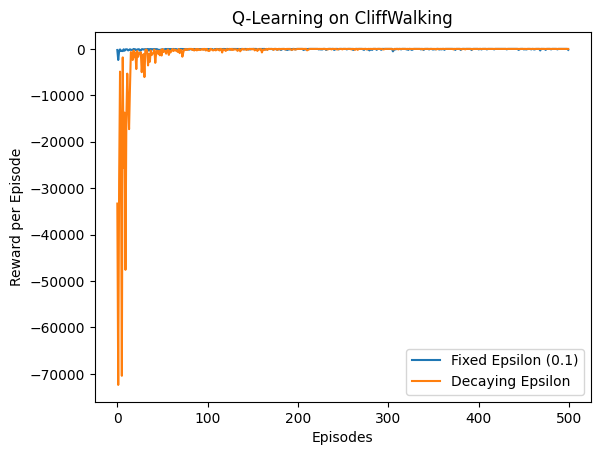

In [40]:
plt.plot(returns_fixed, label="Fixed Epsilon (0.1)")
plt.plot(returns_decay, label="Decaying Epsilon")
plt.xlabel("Episodes")
plt.ylabel("Reward per Episode")
plt.title("Q-Learning on CliffWalking")
plt.legend()
plt.show()

For Decaying Epsilon: 

The orange line drops massively at the beginning because the agent starts with 100% random exploration, causing it to blindly fall off the cliff thousands of times before stumbling to the goal. As the exploration rate decays to near zero, the agent stops taking random risks and perfectly exploits the optimal path which results in a smooth, flat line at the maximum possible score.

For Fixed Epsilon:

The blue line avoids the massive early drop because the agent is capped at only 10% random exploration which relies mostly on its growing knowledge from the start. Because the agent is forced to randomly explore 10% of the time forever, it continues to occasionally jump off the cliff even after learning the correct path which prevents it from achieving a perfectly stable score.

In [26]:
# Evaluation
def evaluate_policy(env, q_table, eval_episodes=100):
    # Turn off Epsilon (ϵ=0). Remove the Bellman Equation entirely.
    successes = 0
    returns = []
    for _ in range(eval_episodes):
        state, _ = env.reset()
        done = False
        truncated = False
        ep_return = 0
        
        while not (done or truncated):
            action = np.argmax(q_table[state]) # STRICT EXPLOITATION
            state, reward, done, truncated, _ = env.step(action)
            ep_return += reward
            
        returns.append(ep_return)
        if ep_return > -100: # If it didn't fall off the cliff
            successes += 1
            
    return np.mean(returns), (successes/eval_episodes)*100

In [27]:
eval_return, success_rate = evaluate_policy(env, q_table_decay)

In [28]:
print(f"\nEvaluation: Average Return: {eval_return}") 
print(f"Evaluation: Success Rate: {success_rate}%")


Evaluation: Average Return: -13.0
Evaluation: Success Rate: 100.0%


In [29]:
def visualize_policy(q_table):
    # Action mapping in CliffWalking: 0: Up, 1: Right, 2: Down, 3: Left
    action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    policy_grid = []
    
    for state in range(48):
        # Find the best action for this state
        best_action = np.argmax(q_table[state])
        policy_grid.append(action_symbols[best_action])
        
    # Reshape into the 4x12 grid
    policy_grid = np.array(policy_grid).reshape(4, 12)
    
    # Overwrite the cliff and goal for visual clarity
    policy_grid[3, 1:11] = 'X' # The Cliff
    policy_grid[3, 11] = 'G'   # The Goal
    
    print("\nLearned Policy (The Cheat Sheet):")
    for row in policy_grid:
        print(" ".join(row))

In [30]:
visualize_policy(q_table_decay)


Learned Policy (The Cheat Sheet):
→ → → → → → → → → → → ↓
→ → → → → → → → → → ↓ ↓
→ → → → → → → → → → → ↓
↑ X X X X X X X X X X G
